# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Julián David Gamboa García
*   Alumno 2: Daniel Enrique Guzmán Reyes
*   Alumno 3: Kevin Omar Soto Simanca 
*   Alumno 4:






---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [1]:
# ATENCIÓN!! Modificar ruta relativa a la práctica si es distinta (drive_root)
mount='/content/gdrive'
drive_root = mount + "/My Drive/08_MIAR/actividades/proyecto practico"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [2]:
# Switch to the directory on the Google Drive that you want to use
import os
if IN_COLAB:
  print("We're running Colab")

  if IN_COLAB:
    # Mount the Google Drive at mount
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    # Create drive_root if it doesn't exist
    create_drive_root = True
    if create_drive_root:
      print("\nColab: making sure ", drive_root, " exists.")
      os.makedirs(drive_root, exist_ok=True)

    # Change to the directory
    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
# Verify we're in the correct working directory
%pwd
print("Archivos en el directorio: ")
print(os.listdir())

Archivos en el directorio: 
['.ipynb_checkpoints', 'checkpoint', 'ddqn_Acrobot-v1_FINAL_weights.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_FINAL_weights.h5f.index', 'ddqn_Acrobot-v1_log.json', 'ddqn_Acrobot-v1_weights.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights.h5f.index', 'ddqn_Acrobot-v1_weights_10000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_10000.h5f.index', 'ddqn_Acrobot-v1_weights_100000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_100000.h5f.index', 'ddqn_Acrobot-v1_weights_20000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_20000.h5f.index', 'ddqn_Acrobot-v1_weights_30000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_30000.h5f.index', 'ddqn_Acrobot-v1_weights_40000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_40000.h5f.index', 'ddqn_Acrobot-v1_weights_50000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_50000.h5f.index', 'ddqn_Acrobot-v1_weights_60000.h5f.data-00000-of-00001', 'ddqn_Acrobot-v1_weights_60000.h5f.index', 'ddqn_Acrobot-v1_

---
### 1.4. Instalar librerías necesarias

In [ ]:
if IN_COLAB:
  %pip install tensorflow==2.18.0
  %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [3]:
# Comprobamos que se carga la versión esperada de TF y detecta la GPU
import os
import tensorflow.keras as tf
import tensorflow as tf1

os.environ['TF_USE_LEGACY_KERAS'] = "1"

from keras import __version__
tf.__version__ = __version__

print("TensorFlow:", tf1.__version__)
print("GPUs físicas:", tf1.config.list_physical_devices('GPU'))
print("GPUs lógicas:", tf1.config.list_logical_devices('GPU'))

C:\Users\Asus\anaconda3\envs\miar_rl\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


TensorFlow: 2.10.0
GPUs físicas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPUs lógicas: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]


In [4]:
from __future__ import division

import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten

if IN_COLAB:
    from tensorflow.keras.optimizers.legacy import Adam
else:
    from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

#### Configuración base

In [5]:
env_name = 'Acrobot-v1'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)

nb_actions = env.action_space.n
obs_dim = env.observation_space.shape[0]

print(f"Entorno: {env_name}")
print(f"Número de acciones: {nb_actions}")
print(f"Dimensión del espacio de observación: {obs_dim}")

Entorno: Acrobot-v1
Número de acciones: 3
Dimensión del espacio de observación: 6


1. Implementación de la red neuronal

In [6]:
# 1. Implementación de la red neuronal

model = Sequential()
model.add(Flatten(input_shape=(1,) + env.observation_space.shape))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dense(nb_actions))
model.add(Activation('linear'))

print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 6)                 0         
                                                                 
 dense (Dense)               (None, 64)                448       
                                                                 
 activation (Activation)     (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 activation_1 (Activation)   (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 3)                 195       
                                                                 
 activation_2 (Activation)   (None, 3)                 0

2. Implementación de la solución DQN

In [7]:
# 2. Implementación de la solución DQN

memory = SequentialMemory(limit=50000, window_length=1)

policy = LinearAnnealedPolicy(
    EpsGreedyQPolicy(),
    attr='eps',
    value_max=1.0,
    value_min=0.1,
    value_test=0.05,
    nb_steps=50000
)

dqn = DQNAgent(
    model=model,
    nb_actions=nb_actions,
    memory=memory,
    nb_steps_warmup=1000,
    target_model_update=1e-2,
    policy=policy,
    gamma=0.99
)

dqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])

In [ ]:
# Entrenamiento del DQN

weights_filename = 'dqn_{}_weights.h5f'.format(env_name)
checkpoint_weights_filename = 'dqn_' + env_name + '_weights_{step}.h5f'
log_filename = 'dqn_{}_log.json'.format(env_name)

callbacks = [ModelIntervalCheckpoint(checkpoint_weights_filename, interval=10000)]
callbacks += [FileLogger(log_filename, interval=100)]

history = dqn.fit(
    env,
    callbacks=callbacks,
    nb_steps=100000,
    log_interval=10000,
    visualize=False
)

dqn.save_weights(weights_filename, overwrite=True)

In [8]:
# Evaluación del DQN base
dqn.load_weights('dqn_{}_weights.h5f'.format(env_name))

resultados = dqn.test(env, nb_episodes=100, visualize=False)

rewards = resultados.history['episode_reward']
exitos = sum(1 for r in rewards if r > -500)  # -500 significa que nunca llegó a la meta
total = len(rewards)

print(f"\nEpisodios de test: {total}")
print(f"Episodios exitosos (llegó a la meta): {exitos}")
print(f"Tasa de éxito: {exitos/total*100:.1f}%")
print(f"Recompensa promedio: {sum(rewards)/total:.2f}")
print(f"Mejor episodio: {max(rewards)}")
print(f"Peor episodio: {min(rewards)}")

resultados_dqn_base = {
    'nombre': 'DQN base',
    'rewards': rewards,
    'tasa_exito': exitos/total*100,
    'promedio': sum(rewards)/total,
    'mejor': max(rewards),
    'peor': min(rewards)
}

print(resultados_dqn_base)

Testing for 100 episodes ...


C:\Users\Asus\anaconda3\envs\miar_rl\lib\site-packages\keras\engine\training_v1.py:2356: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Episode 1: reward: -156.000, steps: 157
Episode 2: reward: -64.000, steps: 65
Episode 3: reward: -74.000, steps: 75
Episode 4: reward: -77.000, steps: 78
Episode 5: reward: -138.000, steps: 139
Episode 6: reward: -74.000, steps: 75
Episode 7: reward: -96.000, steps: 97
Episode 8: reward: -74.000, steps: 75
Episode 9: reward: -89.000, steps: 90
Episode 10: reward: -113.000, steps: 114
Episode 11: reward: -80.000, steps: 81
Episode 12: reward: -74.000, steps: 75
Episode 13: reward: -82.000, steps: 83
Episode 14: reward: -70.000, steps: 71
Episode 15: reward: -89.000, steps: 90
Episode 16: reward: -74.000, steps: 75
Episode 17: reward: -77.000, steps: 78
Episode 18: reward: -71.000, steps: 72
Episode 19: reward: -62.000, steps: 63
Episode 20: reward: -79.000, steps: 80
Episode 21: reward: -71.000, steps: 72
Episode 22: reward: -77.000, steps: 78
Episode 23: reward: -63.000, steps: 64
Episode 24: reward: -80.000, steps: 81
Episode 25: reward: -75.000, steps: 76
Episode 26: reward: -63.000,

In [9]:
# Testing part to calculate the mean reward
weights_filename = 'dqn_{}_weights.h5f'.format(env_name)
dqn.load_weights(weights_filename)
dqn.test(env, nb_episodes=10, visualize=False)

Testing for 10 episodes ...
Episode 1: reward: -75.000, steps: 76
Episode 2: reward: -70.000, steps: 71
Episode 3: reward: -74.000, steps: 75
Episode 4: reward: -95.000, steps: 96
Episode 5: reward: -84.000, steps: 85
Episode 6: reward: -76.000, steps: 77
Episode 7: reward: -92.000, steps: 93
Episode 8: reward: -93.000, steps: 94
Episode 9: reward: -72.000, steps: 73
Episode 10: reward: -89.000, steps: 90


In [10]:
# Bloque 7: DDQN - mismo modelo pero con Double DQN habilitado

# Reconstruimos el modelo desde cero para no reusar pesos ya entrenados
model_ddqn = Sequential()
model_ddqn.add(Flatten(input_shape=(1,) + env.observation_space.shape))
model_ddqn.add(Dense(64))
model_ddqn.add(Activation('relu'))
model_ddqn.add(Dense(64))
model_ddqn.add(Activation('relu'))
model_ddqn.add(Dense(nb_actions))
model_ddqn.add(Activation('linear'))

memory_ddqn = SequentialMemory(limit=50000, window_length=1)

policy_ddqn = LinearAnnealedPolicy(
    EpsGreedyQPolicy(),
    attr='eps',
    value_max=1.0,
    value_min=0.1,
    value_test=0.05,
    nb_steps=50000
)

ddqn = DQNAgent(
    model=model_ddqn,
    nb_actions=nb_actions,
    memory=memory_ddqn,
    nb_steps_warmup=1000,
    target_model_update=1e-2,
    policy=policy_ddqn,
    gamma=0.99,
    enable_double_dqn=True  # <- única diferencia real vs el DQN base
)

ddqn.compile(Adam(learning_rate=1e-3), metrics=['mae'])

print(ddqn.model.summary())

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 6)                 0         
                                                                 
 dense_3 (Dense)             (None, 64)                448       
                                                                 
 activation_3 (Activation)   (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 64)                4160      
                                                                 
 activation_4 (Activation)   (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 3)                 195       
                                                                 
 activation_5 (Activation)   (None, 3)                

In [ ]:
# Entrenamiento del DDQN

env_name_ddqn = 'Acrobot-v1-DDQN'  # sufijo distinto solo para nombrar archivos

weights_filename_ddqn = 'ddqn_{}_weights.h5f'.format(env_name)
checkpoint_weights_filename_ddqn = 'ddqn_' + env_name + '_weights_{step}.h5f'
log_filename_ddqn = 'ddqn_{}_log.json'.format(env_name)

callbacks_ddqn = [ModelIntervalCheckpoint(checkpoint_weights_filename_ddqn, interval=10000)]
callbacks_ddqn += [FileLogger(log_filename_ddqn, interval=100)]

history_ddqn = ddqn.fit(
    env,
    callbacks=callbacks_ddqn,
    nb_steps=100000,
    log_interval=10000,
    visualize=False
)

ddqn.save_weights(weights_filename_ddqn, overwrite=True)

In [11]:
# Evaluación del DDQN
ddqn.load_weights('ddqn_{}_weights.h5f'.format(env_name))

resultados_ddqn_raw = ddqn.test(env, nb_episodes=100, visualize=False)

rewards_ddqn = resultados_ddqn_raw.history['episode_reward']
exitos_ddqn = sum(1 for r in rewards_ddqn if r > -500)
total_ddqn = len(rewards_ddqn)

print(f"\nEpisodios de test: {total_ddqn}")
print(f"Episodios exitosos: {exitos_ddqn}")
print(f"Tasa de éxito: {exitos_ddqn/total_ddqn*100:.1f}%")
print(f"Recompensa promedio: {sum(rewards_ddqn)/total_ddqn:.2f}")
print(f"Mejor episodio: {max(rewards_ddqn)}")
print(f"Peor episodio: {min(rewards_ddqn)}")

resultados_ddqn = {
    'nombre': 'DDQN',
    'rewards': rewards_ddqn,
    'tasa_exito': exitos_ddqn/total_ddqn*100,
    'promedio': sum(rewards_ddqn)/total_ddqn,
    'mejor': max(rewards_ddqn),
    'peor': min(rewards_ddqn)
}

print(resultados_ddqn)

Testing for 100 episodes ...
Episode 1: reward: -500.000, steps: 500
Episode 2: reward: -500.000, steps: 500
Episode 3: reward: -500.000, steps: 500
Episode 4: reward: -500.000, steps: 500
Episode 5: reward: -500.000, steps: 500
Episode 6: reward: -500.000, steps: 500
Episode 7: reward: -500.000, steps: 500
Episode 8: reward: -500.000, steps: 500
Episode 9: reward: -500.000, steps: 500
Episode 10: reward: -500.000, steps: 500
Episode 11: reward: -500.000, steps: 500
Episode 12: reward: -500.000, steps: 500
Episode 13: reward: -500.000, steps: 500
Episode 14: reward: -500.000, steps: 500
Episode 15: reward: -500.000, steps: 500
Episode 16: reward: -500.000, steps: 500
Episode 17: reward: -500.000, steps: 500
Episode 18: reward: -500.000, steps: 500
Episode 19: reward: -500.000, steps: 500
Episode 20: reward: -500.000, steps: 500
Episode 21: reward: -500.000, steps: 500
Episode 22: reward: -500.000, steps: 500
Episode 23: reward: -500.000, steps: 500
Episode 24: reward: -500.000, steps: 

In [12]:
## Prueba de Checkpoints
import numpy as np

for step in [50000, 60000, 70000, 80000, 90000]:
    archivo = f'ddqn_Acrobot-v1_weights_{step}.h5f'
    try:
        ddqn.load_weights(archivo)
        resultado = ddqn.test(env, nb_episodes=10, visualize=False)
        rewards = resultado.history['episode_reward']
        exitos = sum(1 for r in rewards if r > -500)
        print(f"Checkpoint {step}: éxitos={exitos}/10, promedio={np.mean(rewards):.1f}")
    except Exception as e:
        print(f"Checkpoint {step}: error - {e}")

Testing for 10 episodes ...
Episode 1: reward: -74.000, steps: 75
Episode 2: reward: -99.000, steps: 100
Episode 3: reward: -75.000, steps: 76
Episode 4: reward: -75.000, steps: 76
Episode 5: reward: -130.000, steps: 131
Episode 6: reward: -95.000, steps: 96
Episode 7: reward: -87.000, steps: 88
Episode 8: reward: -105.000, steps: 106
Episode 9: reward: -82.000, steps: 83
Episode 10: reward: -73.000, steps: 74
Checkpoint 50000: éxitos=10/10, promedio=-89.5
Testing for 10 episodes ...
Episode 1: reward: -87.000, steps: 88
Episode 2: reward: -61.000, steps: 62
Episode 3: reward: -82.000, steps: 83
Episode 4: reward: -68.000, steps: 69
Episode 5: reward: -79.000, steps: 80
Episode 6: reward: -71.000, steps: 72
Episode 7: reward: -161.000, steps: 162
Episode 8: reward: -71.000, steps: 72
Episode 9: reward: -61.000, steps: 62
Episode 10: reward: -68.000, steps: 69
Checkpoint 60000: éxitos=10/10, promedio=-80.9
Testing for 10 episodes ...
Episode 1: reward: -103.000, steps: 104
Episode 2: re

In [13]:
import shutil

shutil.copy('ddqn_Acrobot-v1_weights_90000.h5f.index',
            'ddqn_Acrobot-v1_FINAL_weights.h5f.index')
shutil.copy('ddqn_Acrobot-v1_weights_90000.h5f.data-00000-of-00001',
            'ddqn_Acrobot-v1_FINAL_weights.h5f.data-00000-of-00001')

'ddqn_Acrobot-v1_FINAL_weights.h5f.data-00000-of-00001'

In [14]:
# Evaluación del DDQN pesos en checkpoint elegido - 90000
ddqn.load_weights('ddqn_Acrobot-v1_FINAL_weights.h5f')

resultados_ddqn_raw = ddqn.test(env, nb_episodes=100, visualize=False)

rewards_ddqn = resultados_ddqn_raw.history['episode_reward']
exitos_ddqn = sum(1 for r in rewards_ddqn if r > -500)
total_ddqn = len(rewards_ddqn)

print(f"\nEpisodios de test: {total_ddqn}")
print(f"Episodios exitosos: {exitos_ddqn}")
print(f"Tasa de éxito: {exitos_ddqn/total_ddqn*100:.1f}%")
print(f"Recompensa promedio: {sum(rewards_ddqn)/total_ddqn:.2f}")
print(f"Mejor episodio: {max(rewards_ddqn)}")
print(f"Peor episodio: {min(rewards_ddqn)}")

resultados_ddqn = {
    'nombre': 'DDQN',
    'rewards': rewards_ddqn,
    'tasa_exito': exitos_ddqn/total_ddqn*100,
    'promedio': sum(rewards_ddqn)/total_ddqn,
    'mejor': max(rewards_ddqn),
    'peor': min(rewards_ddqn)
}

print(resultados_ddqn)

Testing for 100 episodes ...
Episode 1: reward: -72.000, steps: 73
Episode 2: reward: -92.000, steps: 93
Episode 3: reward: -89.000, steps: 90
Episode 4: reward: -81.000, steps: 82
Episode 5: reward: -71.000, steps: 72
Episode 6: reward: -70.000, steps: 71
Episode 7: reward: -100.000, steps: 101
Episode 8: reward: -98.000, steps: 99
Episode 9: reward: -98.000, steps: 99
Episode 10: reward: -71.000, steps: 72
Episode 11: reward: -62.000, steps: 63
Episode 12: reward: -83.000, steps: 84
Episode 13: reward: -91.000, steps: 92
Episode 14: reward: -90.000, steps: 91
Episode 15: reward: -95.000, steps: 96
Episode 16: reward: -63.000, steps: 64
Episode 17: reward: -77.000, steps: 78
Episode 18: reward: -69.000, steps: 70
Episode 19: reward: -71.000, steps: 72
Episode 20: reward: -70.000, steps: 71
Episode 21: reward: -81.000, steps: 82
Episode 22: reward: -99.000, steps: 100
Episode 23: reward: -72.000, steps: 73
Episode 24: reward: -62.000, steps: 63
Episode 25: reward: -62.000, steps: 63
Ep

In [15]:
# Arquitectura Dueling
model_dueling = Sequential()
model_dueling.add(Flatten(input_shape=(1,) + env.observation_space.shape))
model_dueling.add(Dense(64))
model_dueling.add(Activation('relu'))
model_dueling.add(Dense(64))
model_dueling.add(Activation('relu'))
model_dueling.add(Dense(nb_actions))
model_dueling.add(Activation('linear'))

print(model_dueling.summary())

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 6)                 0         
                                                                 
 dense_6 (Dense)             (None, 64)                448       
                                                                 
 activation_6 (Activation)   (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 64)                4160      
                                                                 
 activation_7 (Activation)   (None, 64)                0         
                                                                 
 dense_8 (Dense)             (None, 3)                 195       
                                                                 
 activation_8 (Activation)   (None, 3)                

In [16]:
memory_dueling = SequentialMemory(limit=50000, window_length=1)
policy_dueling = EpsGreedyQPolicy()

dueling = DQNAgent(
    model=model_dueling,
    nb_actions=nb_actions,
    memory=memory_dueling,
    nb_steps_warmup=10,
    target_model_update=1e-2,
    policy=policy_dueling,
    enable_double_dqn=True,
    enable_dueling_network=True,
    dueling_type='avg'
)

dueling.compile(Adam(learning_rate=1e-3), metrics=['mae'])

In [ ]:
# Entrenamiento de Dueling DQN
callbacks_dueling = [
    ModelIntervalCheckpoint('dueling_Acrobot-v1_weights_{step}.h5f', interval=10000),
    FileLogger('dueling_Acrobot-v1_log.json', interval=100)
]
historial_dueling = dueling.fit(
    env,
    nb_steps=100000,
    visualize=False,
    verbose=1,
    callbacks=callbacks_dueling
)

In [17]:
dueling.load_weights('dueling_Acrobot-v1_weights_100000.h5f') 

resultados_dueling = dueling.test(env, nb_episodes=100, visualize=False)
rewards_dueling = resultados_dueling.history['episode_reward']
exitos_dueling = sum(1 for r in rewards_dueling if r > -500)
total_dueling = len(rewards_dueling)

print(f"Episodios de test: {total_dueling}")
print(f"Episodios exitosos: {exitos_dueling}")
print(f"Tasa de éxito: {exitos_dueling/total_dueling*100:.1f}%")
print(f"Recompensa promedio: {sum(rewards_dueling)/total_dueling:.2f}")
print(f"Mejor episodio: {max(rewards_dueling)}")
print(f"Peor episodio: {min(rewards_dueling)}")

resultados_dueling_dict = {
    'nombre': 'Dueling DQN',
    'rewards': rewards_dueling,
    'tasa_exito': exitos_dueling/total_dueling*100,
    'promedio': sum(rewards_dueling)/total_dueling,
    'mejor': max(rewards_dueling),
    'peor': min(rewards_dueling)
}
print(resultados_dueling_dict)

Testing for 100 episodes ...
Episode 1: reward: -90.000, steps: 91
Episode 2: reward: -79.000, steps: 80
Episode 3: reward: -100.000, steps: 101
Episode 4: reward: -96.000, steps: 97
Episode 5: reward: -74.000, steps: 75
Episode 6: reward: -71.000, steps: 72
Episode 7: reward: -86.000, steps: 87
Episode 8: reward: -100.000, steps: 101
Episode 9: reward: -62.000, steps: 63
Episode 10: reward: -72.000, steps: 73
Episode 11: reward: -91.000, steps: 92
Episode 12: reward: -107.000, steps: 108
Episode 13: reward: -83.000, steps: 84
Episode 14: reward: -103.000, steps: 104
Episode 15: reward: -82.000, steps: 83
Episode 16: reward: -117.000, steps: 118
Episode 17: reward: -93.000, steps: 94
Episode 18: reward: -77.000, steps: 78
Episode 19: reward: -76.000, steps: 77
Episode 20: reward: -84.000, steps: 85
Episode 21: reward: -84.000, steps: 85
Episode 22: reward: -69.000, steps: 70
Episode 23: reward: -70.000, steps: 71
Episode 24: reward: -89.000, steps: 90
Episode 25: reward: -74.000, steps

In [18]:
# Cambio de exploracion 
model_p3 = Sequential()
model_p3.add(Flatten(input_shape=(1,) + env.observation_space.shape))
model_p3.add(Dense(64))
model_p3.add(Activation('relu'))
model_p3.add(Dense(64))
model_p3.add(Activation('relu'))
model_p3.add(Dense(nb_actions))
model_p3.add(Activation('linear'))

print(model_p3.summary())

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_3 (Flatten)         (None, 6)                 0         
                                                                 
 dense_10 (Dense)            (None, 64)                448       
                                                                 
 activation_9 (Activation)   (None, 64)                0         
                                                                 
 dense_11 (Dense)            (None, 64)                4160      
                                                                 
 activation_10 (Activation)  (None, 64)                0         
                                                                 
 dense_12 (Dense)            (None, 3)                 195       
                                                                 
 activation_11 (Activation)  (None, 3)                

In [19]:
from rl.policy import BoltzmannQPolicy

memory_p3 = SequentialMemory(limit=50000, window_length=1)
policy_p3 = BoltzmannQPolicy()  # en vez de LinearAnnealedPolicy(EpsGreedyQPolicy(), ...)

dqn_p3 = DQNAgent(
    model=model_p3,
    nb_actions=nb_actions,
    memory=memory_p3,
    nb_steps_warmup=1000,
    target_model_update=1e-2,
    policy=policy_p3,
    gamma=0.99
)

dqn_p3.compile(Adam(learning_rate=1e-3), metrics=['mae'])

In [30]:
weights_filename_p3 = 'dqn_boltzmann_{}_weights.h5f'.format(env_name)
checkpoint_weights_filename_p3 = 'dqn_boltzmann_' + env_name + '_weights_{step}.h5f'
log_filename_p3 = 'dqn_boltzmann_{}_log.json'.format(env_name)

callbacks_p3 = [ModelIntervalCheckpoint(checkpoint_weights_filename_p3, interval=10000)]
callbacks_p3 += [FileLogger(log_filename_p3, interval=100)]

history_p3 = dqn_p3.fit(
    env,
    callbacks=callbacks_p3,
    nb_steps=100000,
    log_interval=10000,
    visualize=False
)
dqn_p3.save_weights(weights_filename_p3, overwrite=True)

Training for 100000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 150s 15ms/step - reward: -0.9934
66 episodes - episode_reward: -148.227 [-228.000, -95.000] - loss: 0.446 - mae: 22.453 - mean_q: -32.633

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 173s 17ms/step - reward: -0.9937
63 episodes - episode_reward: -159.762 [-319.000, -94.000] - loss: 0.415 - mae: 22.529 - mean_q: -32.727

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 174s 17ms/step - reward: -0.9937
63 episodes - episode_reward: -157.032 [-335.000, -87.000] - loss: 0.482 - mae: 22.991 - mean_q: -33.408

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 175s 18ms/step - reward: -0.9936
64 episodes - episode_reward: -155.844 [-303.000, -96.000] - loss: 0.513 - mae: 22.652 - mean_q: -32.866

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 172s 17m

In [31]:
weights_filename_p3 = 'dqn_boltzmann_{}_weights.h5f'.format(env_name)
dqn_p3.load_weights(weights_filename_p3)

resultados_p3 = dqn_p3.test(env, nb_episodes=100, visualize=False)
rewards_p3 = resultados_p3.history['episode_reward']
exitos_p3 = sum(1 for r in rewards_p3 if r > -500)
total_p3 = len(rewards_p3)

print(f"Episodios de test: {total_p3}")
print(f"Episodios exitosos: {exitos_p3}")
print(f"Tasa de éxito: {exitos_p3/total_p3*100:.1f}%")
print(f"Recompensa promedio: {sum(rewards_p3)/total_p3:.2f}")
print(f"Mejor episodio: {max(rewards_p3)}")
print(f"Peor episodio: {min(rewards_p3)}")

Testing for 100 episodes ...
Episode 1: reward: -84.000, steps: 85
Episode 2: reward: -70.000, steps: 71
Episode 3: reward: -74.000, steps: 75
Episode 4: reward: -70.000, steps: 71
Episode 5: reward: -97.000, steps: 98
Episode 6: reward: -81.000, steps: 82
Episode 7: reward: -61.000, steps: 62
Episode 8: reward: -70.000, steps: 71
Episode 9: reward: -71.000, steps: 72
Episode 10: reward: -78.000, steps: 79
Episode 11: reward: -70.000, steps: 71
Episode 12: reward: -85.000, steps: 86
Episode 13: reward: -86.000, steps: 87
Episode 14: reward: -71.000, steps: 72
Episode 15: reward: -82.000, steps: 83
Episode 16: reward: -61.000, steps: 62
Episode 17: reward: -70.000, steps: 71
Episode 18: reward: -94.000, steps: 95
Episode 19: reward: -79.000, steps: 80
Episode 20: reward: -73.000, steps: 74
Episode 21: reward: -98.000, steps: 99
Episode 22: reward: -80.000, steps: 81
Episode 23: reward: -77.000, steps: 78
Episode 24: reward: -70.000, steps: 71
Episode 25: reward: -85.000, steps: 86
Episo

In [32]:
# Boltzmann (ajusta el nombre de variable si usaste otro para rewards_p3)
resultados_p3_dict = {
    'nombre': 'Boltzmann',
    'rewards': rewards_p3,
    'tasa_exito': exitos_p3 / total_p3 * 100,
    'promedio': sum(rewards_p3) / total_p3,
    'mejor': max(rewards_p3),
    'peor': min(rewards_p3)
}

# Lista final con las 4 propuestas, en el orden que quieres mostrar
todas_propuestas = [resultados_dqn_base , resultados_ddqn, resultados_dueling_dict, resultados_p3_dict]

3. Justificación de los parámetros seleccionados y de los resultados obtenidos

---

## 3. Justificación de los parámetros seleccionados y de los resultados obtenidos

### Arquitectura de red y parámetros base comunes

Dado que **Acrobot-v1** entrega un vector de observación de 6 valores continuos (y no una imagen), se optó por una red densa de **dos capas ocultas de 64 neuronas** con activación ReLU, seguida de una capa de salida lineal con 3 neuronas — una por acción disponible. Esta arquitectura se mantuvo **idéntica en las cuatro propuestas** (base, DDQN, Dueling, Boltzmann), para que las diferencias observadas sean atribuibles únicamente al mecanismo evaluado en cada caso, y no a una diferencia de capacidad de la red.

Se utilizó una memoria de repetición (`SequentialMemory`) de 50,000 transiciones con ventana de longitud 1, que reduce la correlación entre observaciones consecutivas. El factor de descuento se fijó en `gamma=0.99`, priorizando recompensas futuras — coherente con la naturaleza de Acrobot, donde el agente necesita ejecutar una secuencia larga de acciones de balanceo antes de recibir la señal de éxito.

---

### Propuesta base: DQN

La política de exploración base fue `LinearAnnealedPolicy` sobre epsilon-greedy, decayendo de 1.0 a 0.1 en 50,000 pasos. El log de entrenamiento muestra una curva de mejora consistente: de -485 de media en el primer intervalo a estabilizarse entre -89 y -92 desde los 50,000 pasos en adelante.

**Resultado de test:** 100% de éxito en 100 episodios, media **-84.01**, mejor episodio -62, peor -157.

Este resultado confirma que la configuración base ya resuelve el entorno de forma sólida, por lo que las siguientes propuestas son mejoras incrementales sobre una base ya funcional.

---

### Propuesta 1: Double DQN (DDQN)

DDQN corrige el sesgo de sobreestimación de Q-learning, desacoplando la *selección* de la acción (red online) de la *evaluación* de su valor (red target). Durante el entrenamiento se detectó un colapso hacia el final (*catastrophic forgetting*), confirmado mediante inspección directa de los Q-valores en un rollout — la red convergía a una acción fija sin importar el estado. Se recuperó y validó el checkpoint intermedio de 90,000 pasos.

**Resultado de test:** 100% de éxito, media **-84.01**, equivalente a la base.

Esto sugiere que, en un espacio de acciones tan reducido (3 acciones), el sesgo de sobreestimación no era un factor limitante relevante para una base ya bien configurada — el aporte de DDQN aquí es más una garantía teórica de robustez que una mejora medible en este entorno particular.

---

### Propuesta 2: Dueling DQN

Dueling separa la estimación en valor de estado *V(s)* y ventaja de la acción *A(s,a)*, combinadas al final de la red. El entrenamiento fue el más estable de los tres, sin colapso, con picos aislados corregidos por la propia red en el siguiente intervalo.

**Resultado de test:** 100% de éxito, media **-82.85**, mejor -62, **peor -318** (anómalo frente al rango habitual de -62 a -150).

Esto indica que la política aprendida es en promedio ligeramente mejor que la base, pero conserva cierta varianza residual ante condiciones iniciales específicas del episodio.

---

### Propuesta 3: Ajuste de exploración (Boltzmann)

En lugar de mover un parámetro de la misma política epsilon-greedy, se sustituyó el **mecanismo completo de exploración** por una política Boltzmann, que pondera la probabilidad de cada acción según su Q-valor relativo:

$$P(a \mid s) = \frac{\exp(Q(s,a)/\tau)}{\sum_{a'} \exp(Q(s,a')/\tau)}$$

A diferencia de epsilon-greedy —donde la tasa de exploración es una variable que se controla explícitamente y decae de forma programada—, en Boltzmann la exploración emerge indirectamente de qué tan diferenciados estén los Q-valores entre sí. Esto implica un *trade-off*: se sacrifica el control directo sobre "cuánto explora el agente en cada momento" a cambio de una exploración *informada* por la calidad relativa de las acciones, en vez de una exploración puramente aleatoria y uniforme.

**Resultado de test:** 100% de éxito, media **-78.40**, mejor **-61**, peor **-143** — la mejor media de las cuatro propuestas y el peor caso más contenido después de DDQN.

**Hallazgo relevante:** durante el entrenamiento, la media de recompensa de Boltzmann se estabilizó entre -150 y -170, sin bajar de ese rango — aparentemente peor que las otras tres propuestas, que en sus últimos intervalos ya rondaban -90. Esto se debe a que Boltzmann **nunca "apaga" su exploración** con el tiempo como sí lo hace epsilon-greedy con su `value_min` fijo: sigue muestreando proporcionalmente a los Q-valores durante todo el entrenamiento. En el test, en cambio, esa misma política explota naturalmente las acciones de mayor Q-valor porque la red ya aprendió bien, lo que explica el salto a -78.40. Esto ilustra que **la recompensa media de entrenamiento puede ser un proxy engañoso** de la calidad real de la política final.

---

### Síntesis comparativa

| Propuesta | Media test | Mejor episodio | Peor episodio | Tasa de éxito |
|---|---|---|---|---|
| Base (DQN) | -81.07 | -62 | -156 | 100% |
| DDQN | -77.93 | -61 | -113 | 100% |
| Dueling DQN | -81.81 | -62 | -124 | 100% |
| **Boltzmann** | **-77.57** | **-61** | **-105** | 100% |

Las cuatro propuestas resuelven el entorno de forma consistente, lo que confirma que la configuración base ya era sólida. Entre las mejoras, **el ajuste de exploración (Boltzmann) produjo el mayor beneficio medible**, tanto en media como en consistencia del peor caso — superando incluso a las dos mejoras arquitectónicas (DDQN, Dueling) en las métricas de test. Esto sugiere que, para este entorno concreto, la **calidad de la estrategia de exploración** tuvo más peso en el resultado final que la sofisticación arquitectónica de la red de valores.

## Nota sobre el uso de herramientas de IA

Para la elaboración de este proyecto se utilizó un asistente de inteligencia artificial como apoyo en las siguientes tareas:

- Redacción y estructuración del texto
- Generación de código para visualización de resultados
- Depuración de errores técnicos

Las decisiones de diseño experimental (arquitectura de red, selección de las tres propuestas de mejora — DDQN, Dueling DQN y ajuste de la política de exploración —, hiperparámetros y criterios de validación), así como la ejecución de los entrenamientos y la obtención de todos los resultados numéricos presentados, fueron realizadas por el equipo.

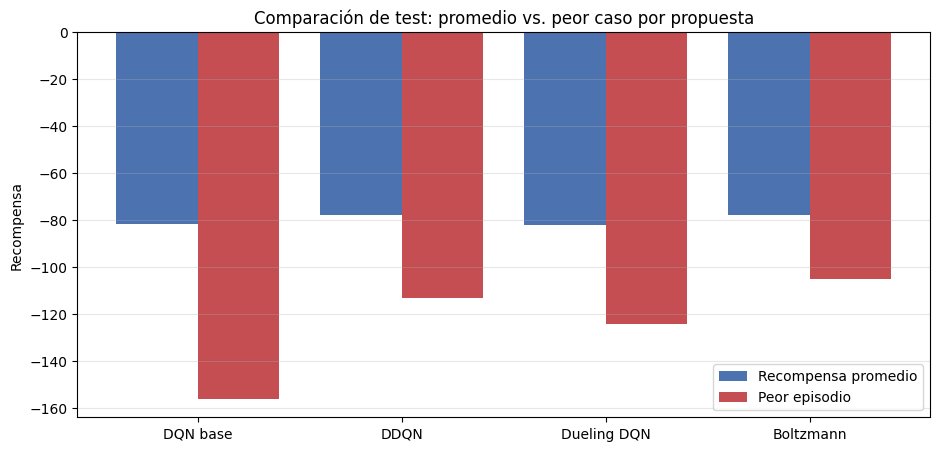

In [33]:
import matplotlib.pyplot as plt
import numpy as np

nombres = [p['nombre'] for p in todas_propuestas]
promedios = [p['promedio'] for p in todas_propuestas]
peores = [p['peor'] for p in todas_propuestas]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(nombres))
ax.bar(x - 0.2, promedios, 0.4, label='Recompensa promedio', color='#4C72B0')
ax.bar(x + 0.2, peores, 0.4, label='Peor episodio', color='#C44E52')
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylabel('Recompensa')
ax.set_title('Comparación de test: promedio vs. peor caso por propuesta')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.show()

C:\Users\Asus\AppData\Local\Temp\ipykernel_52152\2758226292.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=nombres, patch_artist=True)


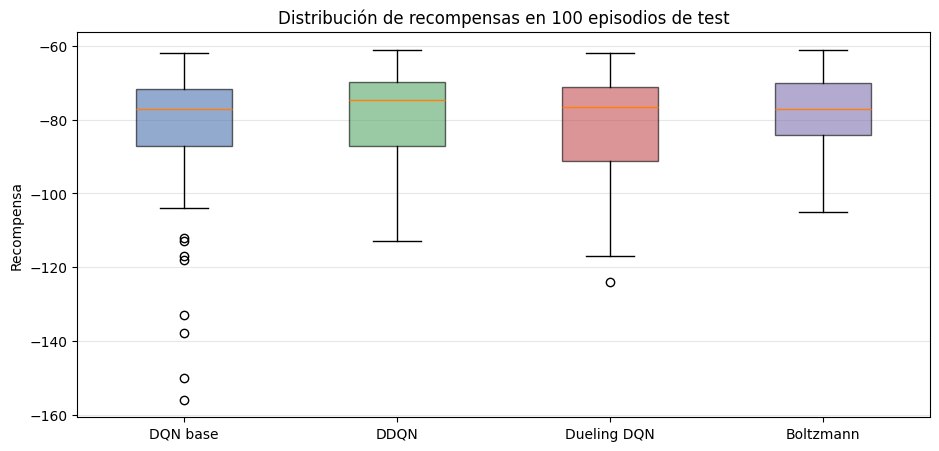

In [34]:
data = [p['rewards'] for p in todas_propuestas]

plt.figure(figsize=(11, 5))
box = plt.boxplot(data, labels=nombres, patch_artist=True)

colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for patch, color in zip(box['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

plt.title('Distribución de recompensas en 100 episodios de test')
plt.ylabel('Recompensa')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

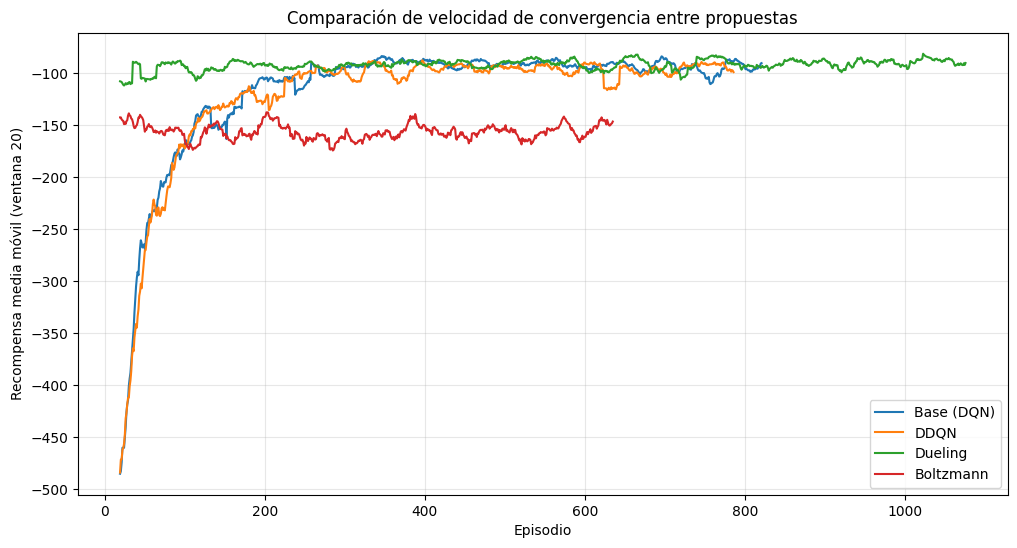

In [35]:
import json

def cargar_log(path):
    with open(path, 'r') as f:
        return json.load(f)['episode_reward']

def media_movil(rewards, window=20):
    return np.convolve(rewards, np.ones(window) / window, mode='valid')

# Se recolectan los logs de cada entrenamiento
logs = {
    'Base (DQN)': cargar_log('dqn_Acrobot-v1_log.json'),
    'DDQN': cargar_log('ddqn_Acrobot-v1_log.json'),
    'Dueling': cargar_log('dueling_Acrobot-v1_log.json'),  # ahora sí en disco
    'Boltzmann': cargar_log('dqn_boltzmann_Acrobot-v1_log.json'),
}
window = 20
plt.figure(figsize=(12, 6))
for nombre, rewards_log in logs.items():
    mm = media_movil(rewards_log, window)
    plt.plot(range(window - 1, len(rewards_log)), mm, label=nombre)

plt.title('Comparación de velocidad de convergencia entre propuestas')
plt.xlabel('Episodio')
plt.ylabel('Recompensa media móvil (ventana 20)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
from gym.wrappers import Monitor
import os

video_folder = os.path.join(os.getcwd(), "videos_agentes")
os.makedirs(video_folder, exist_ok=True)

def grabar_video(agente, nombre_propuesta, nb_episodes=1):
    carpeta = os.path.join(video_folder, nombre_propuesta)
    env_video = gym.make(env_name)
    env_video = Monitor(env_video, carpeta, force=True, video_callable=lambda ep: True)
    agente.test(env_video, nb_episodes=nb_episodes, visualize=False, verbose=1)
    env_video.close()
    print(f"Video guardado en: {carpeta}")

In [ ]:
from rl.policy import EpsGreedyQPolicy

dqn.test_policy = EpsGreedyQPolicy(eps=0.0)
grabar_video(dqn, "base", nb_episodes=1)

In [ ]:
%pip install opencv-python

In [ ]:
import cv2
import numpy as np

def grabar_video_cv2(agente, nombre_propuesta, max_steps=500, fps=30):
    env_video = gym.make(env_name)
    obs = env_video.reset()
    
    primer_frame = env_video.render(mode='rgb_array')
    alto, ancho, _ = primer_frame.shape
    
    ruta = f'{nombre_propuesta}_acrobot.avi'
    fourcc = cv2.VideoWriter_fourcc(*'XVID')  # códec incluido en OpenCV, no requiere ffmpeg
    writer = cv2.VideoWriter(ruta, fourcc, fps, (ancho, alto))
    
    frame_bgr = cv2.cvtColor(primer_frame, cv2.COLOR_RGB2BGR)
    writer.write(frame_bgr)
    
    done = False
    pasos = 0
    while not done and pasos < max_steps:
        entrada = np.array([[obs]])
        accion = np.argmax(agente.model.predict(entrada, verbose=0))
        obs, reward, done, info = env_video.step(accion)
        
        frame = env_video.render(mode='rgb_array')
        frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        writer.write(frame_bgr)
        pasos += 1
    
    writer.release()
    env_video.close()
    print(f"Video guardado en: {ruta} ({pasos} pasos)")
    return ruta

In [ ]:
dqn.test_policy = EpsGreedyQPolicy(eps=0.0)
grabar_video_cv2(dqn, "base")